# Resumen — Primer Parcial: Aprendizaje Automático II
- **Luis Pablo López Iracheta**

---
## Contenido
1. La neurona artificial
2. Funciones de activación
3. Perceptrón multicapa (MLP)
4. Backpropagation
5. Ejemplo: Forward pass numérico
6. Diseño avanzado e inicialización de pesos
7. Ejercicios tipo examen resueltos
8. Implementación en Keras

---
## 1. La neurona artificial

La neurona es la unidad básica de una red neuronal. Utiliza **todas las entradas** ($x_i$) para realizar una **suma ponderada**, donde cada entrada tiene un peso asociado ($w_i$). Además, incluye un término independiente llamado **bias** ($b$) que permite desplazar el hiperplano decisorio.

$$z = b + \sum_{i=1}^{d} w_i x_i = w_0 + \mathbf{w}^T \mathbf{x}$$

La salida de la neurona se obtiene aplicando una **función de activación** $f$ sobre $z$:

$$y = f(z)$$

El resultado estará determinado por el **valor de los parámetros** ($w$, $b$). Por lo tanto, hay que **aprender esos pesos** durante el entrenamiento.

In [1]:
import numpy as np

# Neurona simple con suma ponderada
def neurona(x, w, b):
    """Calcula la suma ponderada z = w·x + b"""
    return np.dot(w, x) + b

# Ejemplo del ejercicio 2 de los apuntes
x = np.array([5, 2, 4, 3])
w = np.array([-1, 3, 1, 0])
b = 3

z = neurona(x, w, b)
print(f"z = {z}")  # Esperado: 8

z = 8


---
## 2. Funciones de activación

La función de activación sirve como una **abstracción** de qué neuronas intervienen en el proceso de clasificación. Simplifica y orienta el aprendizaje al introducir **no linealidad**.

### 2.1 Función escalón (Heaviside)

$$\theta(z) = \begin{cases} 0 & \text{si } z \leq 0 \\ 1 & \text{si } z > 0 \end{cases}$$

- Usada en el perceptrón original
- **No diferenciable** en $z=0$ → no sirve para backprop

### 2.2 Sigmoidal (logística)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Salida acotada en $[0, 1]$
- **Ideal para clasificación binaria**
- Desventaja: pequeñas variaciones en los extremos (gradientes muy pequeños → *vanishing gradient*)

### 2.3 ReLU (Rectified Linear Unit)

$$\text{ReLU}(x) = \max(0, x)$$

- La función más usada en Deep Learning
- Favorece **activaciones dispersas** → más eficiente
- Hasta **6× más rápido** que sigmoidal en entrenamiento
- **Ideal para capas ocultas y regresión**
- **Dying ReLU problem**: algunas neuronas dejan de aprender y quedan bloqueadas en estado de no activación

### 2.4 Softmax — salida multiclase

$$\text{softmax}(z_j) = \frac{e^{z_j}}{\sum_k e^{z_k}}$$

- Convierte vectores reales arbitrarios en **probabilidades normalizadas**
- Todas las clases tienen valor de probabilidad **mayor a cero** y **suman 1**
- Usada en la **capa de salida para clasificación multiclase**

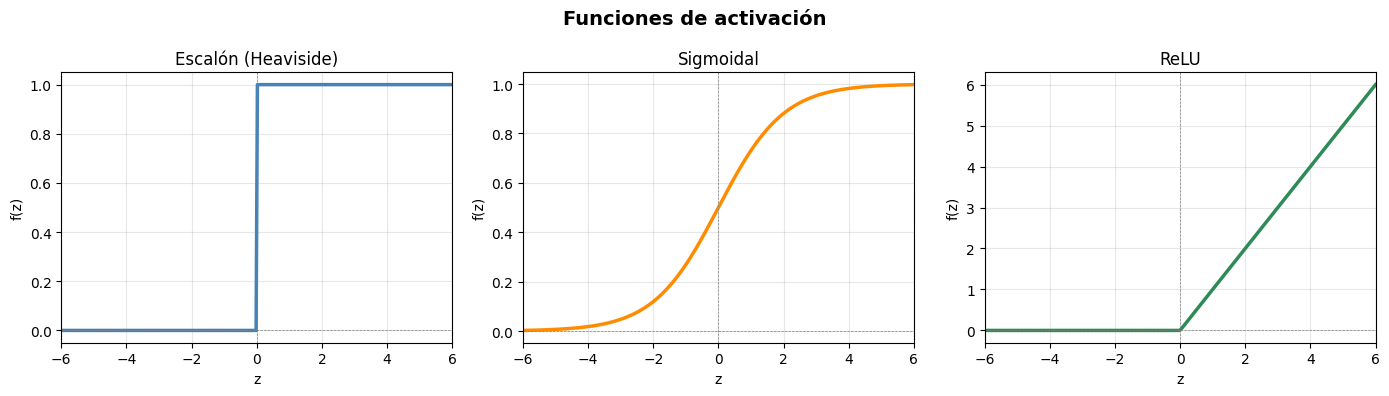

In [2]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 300)

def escalon(z):   return np.where(z > 0, 1, 0)
def sigmoid(z):   return 1 / (1 + np.exp(-z))
def relu(z):      return np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Funciones de activación', fontsize=14, fontweight='bold')

for ax, fn, nombre, color in zip(
    axes,
    [escalon, sigmoid, relu],
    ['Escalón (Heaviside)', 'Sigmoidal', 'ReLU'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.plot(z, fn(z), color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.5, linestyle='--')
    ax.axvline(0, color='gray', lw=0.5, linestyle='--')
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-6, 6)

plt.tight_layout()
plt.show()

In [3]:
# Softmax — demostración
def softmax(z):
    e = np.exp(z - np.max(z))  # estabilidad numérica
    return e / e.sum()

# Ejemplo de los apuntes: [0.25, 0.85, 0.15] → normalizado
logits = np.array([0.25, 0.85, 0.15])
probs  = softmax(logits)
print("Logits:        ", logits)
print("Probabilidades:", np.round(probs, 4))
print("Suma:          ", probs.sum())  # Siempre 1.0

Logits:         [0.25 0.85 0.15]
Probabilidades: [0.2683 0.4889 0.2428]
Suma:           1.0


---
## 3. Perceptrón Multicapa (MLP)

Para problemas más complejos se utilizan **más neuronas y capas**. Cada capa extrae características más complejas. A este tipo de red se le denomina **Multilayer Perceptron (MLP)**.


Entrada → [Capas Ocultas] → Salida


| Tipo de problema | Activación salida | Función de pérdida |
|---|---|---|
| **Multiclase** | `softmax` | `sparse_categorical_crossentropy` (enteros) / `categorical_crossentropy` (one-hot) |
| **Regresión** | `linear` o `relu` | `mean_squared_error` / `mean_absolute_error` |
| **Binario** | `sigmoid` (1 neurona) | `binary_crossentropy` |

### Visualización
- **Clasificación** → Matriz de confusión
- **Regresión** → Gráfica predicho vs. real

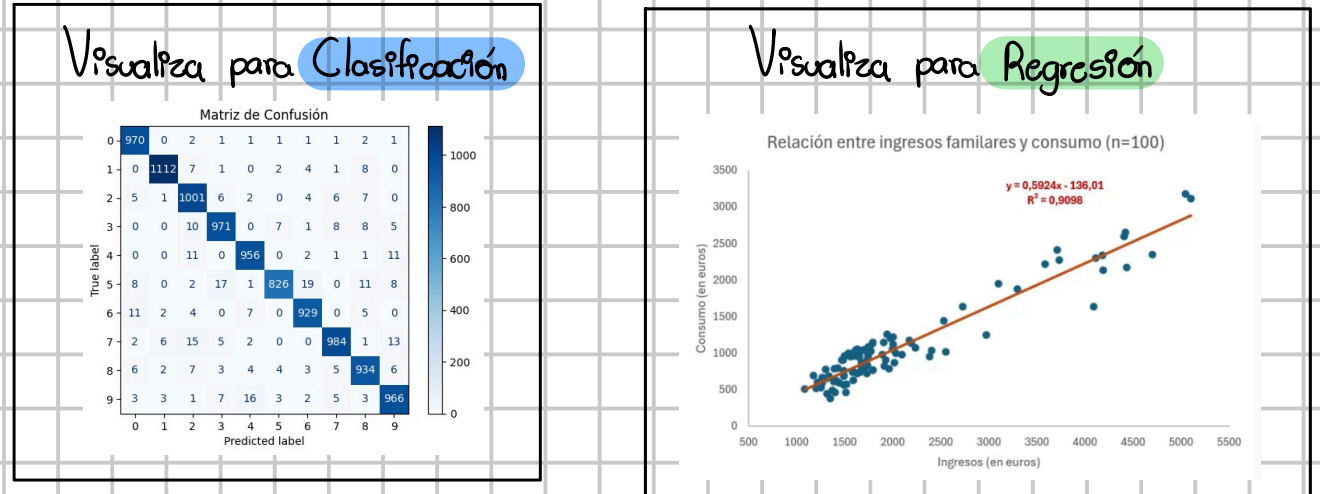

In [4]:
# Ejemplo MLP básico en Keras (multiclase)
import tensorflow as tf
import keras

# 1. Definir arquitectura
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(4,)),   # capa oculta 1
    keras.layers.Dense(32, activation='relu'),                      # capa oculta 2
    keras.layers.Dense(3,  activation='softmax')                   # capa salida multiclase
])

# 2. Compilar
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\IBERO\A2Verano\ML2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Backpropagation

Su principal función es **minimizar el error** entre la salida predicha por la red y la salida deseada, **ajustando los pesos y sesgos** de la NN.

### Dos fases principales

**Propagación hacia adelante (Forward Pass)**
- Los datos se procesan de la capa de entrada hacia la capa de salida
- Se calcula el **costo / error** con la función de pérdida

**Propagación hacia atrás (Backward Pass)**
- El error calculado se propaga hacia atrás (de salida → entrada)
- Se utiliza **descenso de gradiente** + **regla de la cadena**
- Actualización de pesos:

$$w_{t+1} = w_t - \eta \nabla J(w_t)$$

donde $\eta$ es la **tasa de aprendizaje** (learning rate).

### Flujo completo en Keras

```python
model = Sequential(...)           # 1. Definir arquitectura
model.compile(opt, loss, metrics) # 2. Configurar entrenamiento
model.fit(X_train, y_train, ...)  # 3. Entrenar (forward + backward)
model.evaluate(X_test, y_test)    # 4. Evaluar en test
model.predict(X_test)             # 5. Inferencia
```

---
## 5. Ejemplo: Forward pass numérico

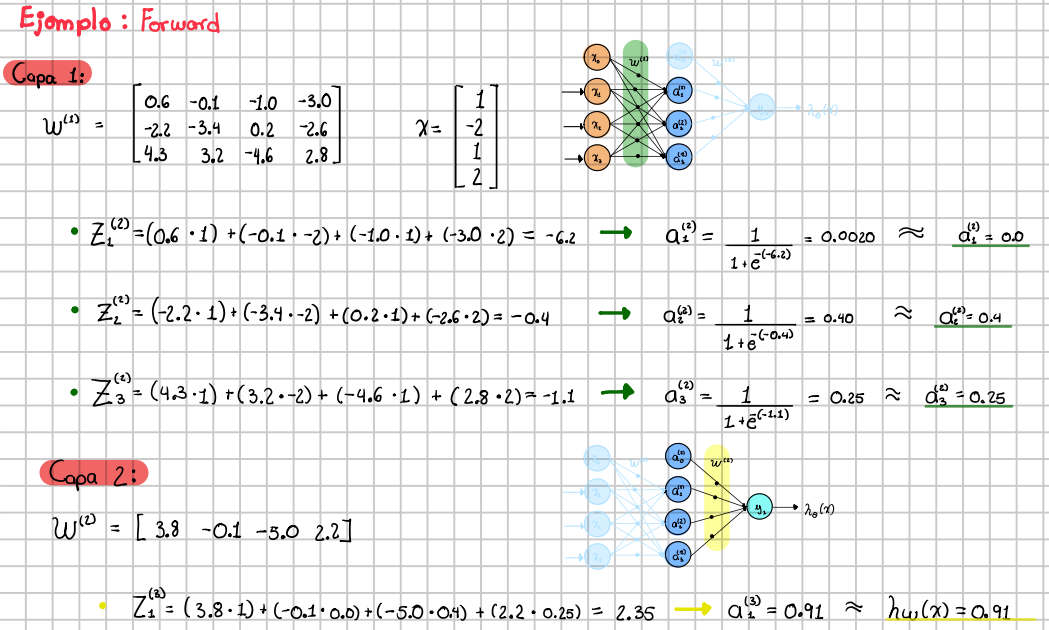

In [5]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Ejemplo
x = np.array([1, -2, 1, 2])

W1 = np.array([
    [ 0.6, -0.1, -1.0, -3.0],
    [-2.2, -3.4,  0.2, -2.6],
    [ 4.3,  3.2, -4.6,  2.8]
])
b1 = np.zeros(3)  # bias capa 1 (3 neuronas)

W2 = np.array([3.8, -0.1, -5.0, 2.2])
b2 = 0.0

# Forward Pass
# Capa 1
z1 = W1 @ x + b1 # suma ponderada capa 1
a1 = sigmoid(z1) 

print("── Capa 1 ──")
for i, (zi, ai) in enumerate(zip(z1, a1), 1):
    print(f"  Z{i} = {zi:.2f}  →  σ(Z{i}) = {ai:.4f}")

# Entrada capa 2: bias node (1) + activaciones capa 1
a1_ext = np.concatenate([[1.0], a1])  # agrega bias node

# Capa 2
z2 = W2 @ a1_ext + b2
a2 = sigmoid(z2)

print(f"\n── Capa 2 ──")
print(f"  Z1 = {z2:.4f}  →  σ(Z1) = {a2:.4f}")
print(f"\n✅ Salida final h_w(x) = {a2:.4f}")

── Capa 1 ──
  Z1 = -6.20  →  σ(Z1) = 0.0020
  Z2 = -0.40  →  σ(Z2) = 0.4013
  Z3 = -1.10  →  σ(Z3) = 0.2497

── Capa 2 ──
  Z1 = 2.3427  →  σ(Z1) = 0.9123

✅ Salida final h_w(x) = 0.9123


---
## 6. Diseño avanzado — Inicialización de pesos

### El Problema de la Simetría

Si inicializamos **todos los pesos con el mismo valor**, todas las neuronas de una capa oculta calcularán **exactamente la misma salida y el mismo gradiente**. Esto hace que la red actúe como si tuviera **una sola neurona por capa**.

Para romper este problema, usamos una **distribución estadística** con dos métodos:

### 6.1 Inicialización Xavier / Glorot
Utilizada principalmente con activaciones simétricas como **tanh**. Asume distribución con **media 0** y calcula la varianza ideal basándose en el tamaño de la capa:

$$W \sim \mathcal{N}\left(0,\ \frac{2}{n_{in} + n_{out}}\right)$$

### 6.2 Inicialización He / Kaiming
Cuando se inventó **ReLU**, Xavier empezó a fallar porque ReLU descarta todos los valores negativos (los vuelve cero), apagando estadísticamente la mitad de las neuronas. He propuso **multiplicar la varianza por 2**:

$$W \sim \mathcal{N}\left(0,\ \frac{2}{n_{in}}\right)$$

Al tener un denominador más pequeño, los pesos iniciales de He tienden a ser un poco más grandes, lo que **mantiene viva la señal** a través de las capas ReLU.

| Inicialización | Activación recomendada | Varianza |
|---|---|---|
| **Xavier / Glorot** | `tanh`, `sigmoid` | $2/(n_{in}+n_{out})$ |
| **He / Kaiming** | `relu` | $2/n_{in}$ |

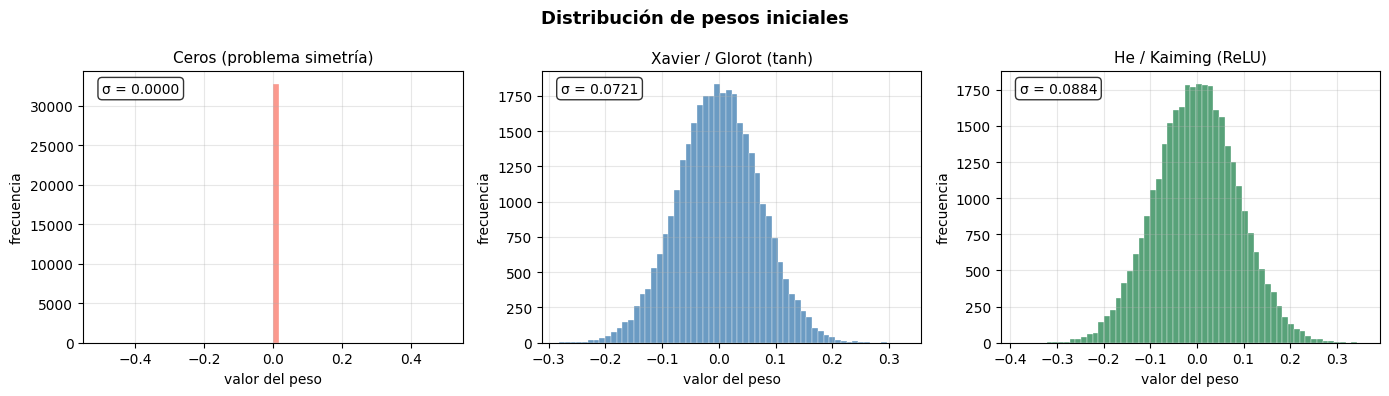

In [6]:
import numpy as np
import matplotlib.pyplot as plt

n_in, n_out = 256, 128
n_samples   = 5000

# Inicializaciones
W_zeros  = np.zeros((n_in, n_out))
W_xavier = np.random.normal(0, np.sqrt(2 / (n_in + n_out)), (n_in, n_out))
W_he     = np.random.normal(0, np.sqrt(2 / n_in),           (n_in, n_out))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución de pesos iniciales', fontsize=13, fontweight='bold')

for ax, W, titulo, color in zip(
    axes,
    [W_zeros, W_xavier, W_he],
    ['Ceros (problema simetría)', 'Xavier / Glorot (tanh)', 'He / Kaiming (ReLU)'],
    ['salmon', 'steelblue', 'seagreen']
):
    ax.hist(W.flatten(), bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('valor del peso')
    ax.set_ylabel('frecuencia')
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.92, f'σ = {W.std():.4f}', transform=ax.transAxes,
            fontsize=10, color='black', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

---
## 8. Implementación completa en Keras

### Flujo estándar de entrenamiento

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8679 - loss: 0.7006 - val_accuracy: 0.9485 - val_loss: 0.3728
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9428 - loss: 0.3695 - val_accuracy: 0.9618 - val_loss: 0.3014
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9554 - loss: 0.3060 - val_accuracy: 0.9667 - val_loss: 0.2604
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9627 - loss: 0.2678 - val_accuracy: 0.9717 - val_loss: 0.2337
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9674 - loss: 0.2424 - val_accuracy: 0.9722 - val_loss: 0.2219
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9709 - loss: 0.2243 - val_accuracy: 0.9758 - val_loss: 0.2109
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9726 - loss: 0.2111 - val_accuracy: 0.9725 - val_loss: 0.2081
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9730 - loss: 0.2024 - val_accuracy: 0.

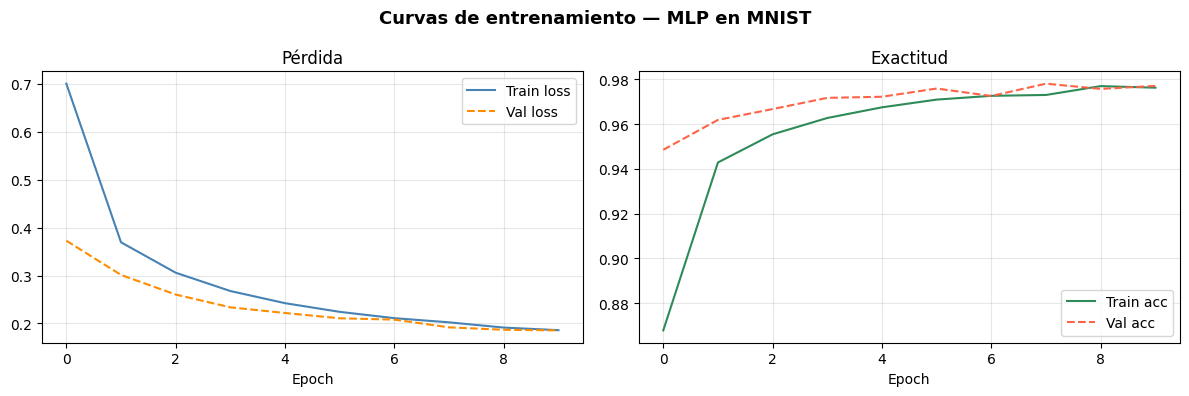

In [7]:
import numpy as np
import tensorflow as tf
from keras import regularizers
import matplotlib.pyplot as plt

# MNIST (dígitos)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocesamiento
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 784).astype('float32') / 255.0


model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,),
                       kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(0.001)),  # Se añade regularización L2, que penaliza pesos grandes
    keras.layers.Dense(32, activation='relu',
                       kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(0.001)),  
    keras.layers.Dense(10, activation='softmax')
])
# 2. Compilar
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Entrenar
historia = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# 4. Evaluar
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {acc:.4f}")

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Curvas de entrenamiento — MLP en MNIST', fontsize=13, fontweight='bold')

axes[0].plot(historia.history['loss'],     label='Train loss', color='steelblue')
axes[0].plot(historia.history['val_loss'], label='Val loss',   color='darkorange', linestyle='--')
axes[0].set_title('Pérdida'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(historia.history['accuracy'],     label='Train acc', color='seagreen')
axes[1].plot(historia.history['val_accuracy'], label='Val acc',   color='tomato', linestyle='--')
axes[1].set_title('Exactitud'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

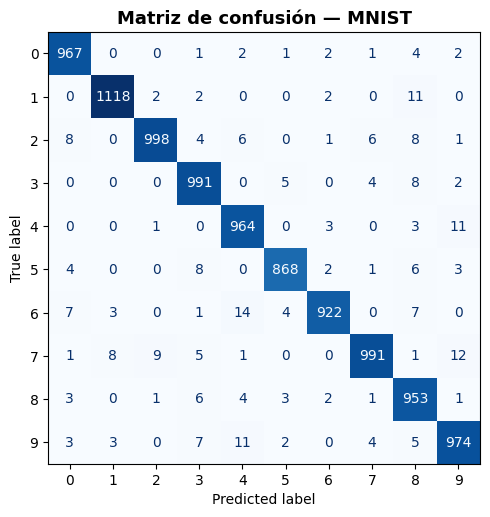

In [8]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(5, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

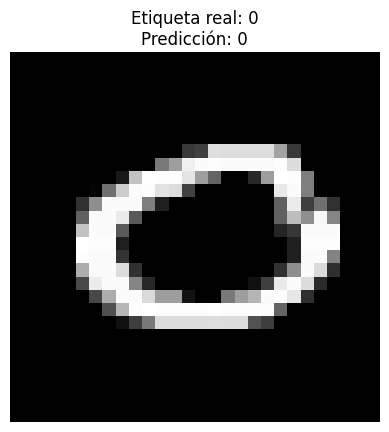

In [10]:
# Preducción de numero vs etiqueta
import random
idx = random.randint(0, len(X_test)-1)
img = X_test[idx].reshape(28, 28)
plt.imshow(img, cmap='gray')
plt.title(f"Etiqueta real: {y_test[idx]}\nPredicción: {np.argmax(model.predict(X_test[idx:idx+1], verbose=0))}", fontsize=12)
plt.axis('off')
plt.show()


## 9 Preguntas antes del examen:



**1. ¿Qué es la inteligencia artificial?**  
Es el esfuerzo por automatizar tareas intelectuales que normalmente realizan los humanos, como el razonamiento, el aprendizaje, la percepción y la toma de decisiones.

**2. ¿En qué año se cristalizó la IA como campo de investigación?**  
En 1956, durante la Conferencia de Dartmouth.

**3. ¿Qué profesor organizó el congreso de Dartmouth?**  
John McCarthy.

**4. ¿Cuál fue el paradigma dominante de la IA en 1980?**  
La IA simbólica, basada en manipulación de símbolos y reglas lógicas.

**5. ¿Cuáles fueron las principales IAs de los años 80 basadas en la IA simbólica?**  
Los sistemas expertos.

**6. ¿Cuál fue la limitación principal de la IA simbólica que llevó a la creación del Machine Learning?**  
La dificultad para modelar problemas reales como reconocimiento de imágenes, debido a la falta de reglas explícitas.

**7. Diferencia entre Machine Learning y la programación tradicional**  
En programación tradicional se escriben reglas explícitas. En Machine Learning el sistema descubre automáticamente los patrones y reglas a partir de los datos.

**8. ¿Quién fue la pionera que afirmó en 1843 que la Máquina Analítica solo podría realizar lo que supiéramos ordenarle?**  
Ada Lovelace.

**9. Artículo donde Turing introdujo el término "Test de Turing" en 1950**  
"Computing Machinery and Intelligence".

**10. ¿Qué es el entrenamiento en Machine Learning?**  
Es el proceso mediante el cual el algoritmo encuentra patrones estadísticos en los datos para automatizar tareas.

**11. ¿En qué sentido difiere el Machine Learning de la estadística clásica?**  
El ML es una disciplina de ingeniería para manejar datos masivos y complejos, mientras que la estadística clásica trabaja con muestras más pequeñas y supuestos más estrictos.

**12. Tres elementos necesarios para realizar Machine Learning**  
Puntos de entrada (datos), ejemplos de salida esperada (etiquetas) y una medida de desempeño (función de pérdida).

**13. Problema central del Machine Learning y el Deep Learning**  
Transformar los datos de entrada para aprender representaciones útiles que se acerquen a la salida esperada.

**14. ¿Qué es "representación" en el contexto del procesamiento de datos?**  
Es la forma de mostrar, codificar o transformar los datos para facilitar una tarea.

**15. ¿Qué es el aprendizaje en Machine Learning?**  
Es la búsqueda automática dentro de un espacio de utilidades (funciones o reglas) que minimicen el error.

**16. ¿Qué es la profundidad en Deep Learning?**  
Usar múltiples capas sucesivas en el modelo. Un modelo superficial usa solo 1 o 2 capas.

**17. Definición de redes neuronales**  
Modelos matemáticos para aprender representaciones estructuradas en capas jerárquicas apiladas unas sobre otras.

**18. ¿Por qué es engañoso decir que el Deep Learning está modelado según el cerebro humano?**  
Porque las redes no saben actuar ante situaciones no vistas previamente como el cerebro humano, y no hay evidencia de que el cerebro funcione con retropropagación o capas profundas.

**19. Analogía para entender las capas del Deep Learning**  
Un filtro de agua: cada capa elimina o transforma ciertas características y pasa una representación más purificada a la siguiente.

**20. ¿Qué son los pesos en una red neuronal?**  
Números que la capa aplica a sus datos de entrada para transformarlos.

**21. ¿Qué es la función de pérdida?**  
Mide qué tan lejos está la salida del modelo del valor esperado.

**22. ¿Qué componente de la red utiliza la función de pérdida para optimizarse?**  
El optimizador.

**23. Algoritmo más utilizado para optimizar redes neuronales**  
Backpropagation (retropropagación del error).

**24. Proceso de ajuste pequeño a la red con ejemplos**  
Bucle de entrenamiento: forward pass, calcular pérdida, backpropagation, actualizar pesos.

**25. Machine Learning vs. Ingeniería de características**  
El ML moderno aprende características automáticamente. La ingeniería de características es el proceso manual de crearlas.

**26. ¿Qué es la ingeniería de características?**  
Transformar datos crudos en representaciones que faciliten el aprendizaje del modelo.

**27. ¿Qué ha hecho que el Machine Learning aumente en los últimos años?**  
Más GPUs y entrenar con datos de manera más eficiente.

**28. ¿Qué son los modelos fundacionales en aprendizaje de datos?**  
Modelos entrenados a muy gran escala con enormes cantidades de datos, adaptables a múltiples tareas (ej. GPT, BERT, DALL·E).